<a href="https://colab.research.google.com/github/Elizabethav03/My_undergrad_ml_assignments/blob/main/Project_1_Wrangling_EDA_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).



### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)

In [ ]:
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

In [ ]:
df[['ELIGSTAT','MORTSTAT','PERMTH_INT','RIDAGEEX']].describe()

df['MORTSTAT'].value_counts()
df['ELIGSTAT'].value_counts()


,count
ELIGSTAT,
1,5445
2,4517
3,3


In [ ]:
df = df[df['ELIGSTAT'] == 1]


In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)


,0
DMAETHN,0.999633
DMARACE,0.999633
DMDSCHOL,0.896235
DMDEDUC3,0.895684
DMDYRSUS,0.728742
UCOD_LEADING,0.692562
DIABETES,0.692562
HYPERTEN,0.692562
DMDHSEDU,0.680441
RIDPREG,0.664279


In [ ]:
vars_to_keep = ['RIDAGEEX','RIAGENDR','RIDRETH1','INDFMPIR','MORTSTAT','PERMTH_INT']
df[vars_to_keep].isna().mean()


,0
RIDAGEEX,0.111111
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,0.154454
MORTSTAT,0.000000
PERMTH_INT,0.000000


The variable ELIGSTAT indicates whether a participant was eligible for mortality linkage.
A value of 1 means the participant was eligible for follow-up through the National Death Index.
A value of 2 indicates the participant was under age 18 and not eligible for public mortality release.
A value of 3 indicates insufficient identifying information for linkage.
Since mortality information is only available for eligible adults, we restricted the analysis to participants with ELIGSTAT = 1.

MORTSTAT represents mortality status at the end of follow-up (December 31, 2019).
A value of 0 indicates the participant is assumed alive, and a value of 1 indicates the participant is assumed deceased.
This variable is used as the outcome for the classification task.

PERMTH_INT measures the number of person-months from the interview date until death or the end of the follow-up period.
It represents survival time and is used as the outcome for the regression task.

RIDAGEEX represents age in months at the time of the MEC exam. In NHANES, age in years (RIDAGEYR) is top-coded at 85 for confidentiality.

We selected age (RIDAGEEX), gender (RIAGENDR), race/ethnicity (RIDRETH1), and income-to-poverty ratio (INDFMPIR) as predictors of mortality and life expectancy.
Age is closely related to mortality risk. Gender and race capture differences in health outcomes across groups. Income reflects socioeconomic status, which is associated with long-term health and survival.

After restricting the dataset to participants eligible for mortality follow-up (ELIGSTAT = 1), MORTSTAT and PERMTH_INT had no missing values.
Age and income had moderate missingness (about 11% and 15%), so we retained these variables for analysis.

# EDA Visualizations:

Basic Summary Statistics:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_vars = ['RIDAGEEX', 'PERMTH_INT', 'INDFMPIR']

df[numeric_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
RIDAGEEX,4840.0,553.576240,235.457568,2.160000e+02,343.75,530.00,758.0000,1019.0
PERMTH_INT,5445.0,202.314601,67.137767,0.000000e+00,194.00,235.00,242.0000,250.0
INDFMPIR,4604.0,2.436670,1.607523,5.397605e-79,1.07,2.04,3.8725,5.0


Skewness:

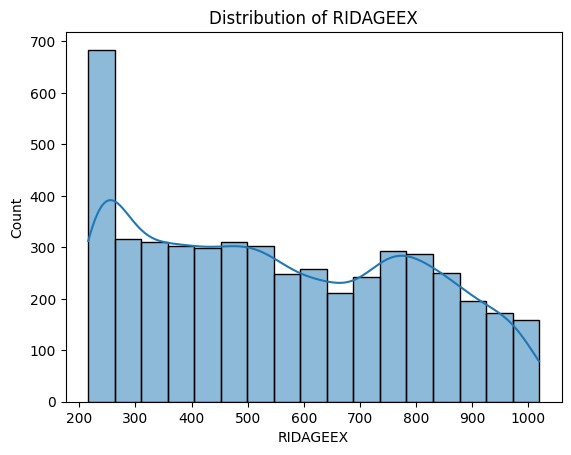

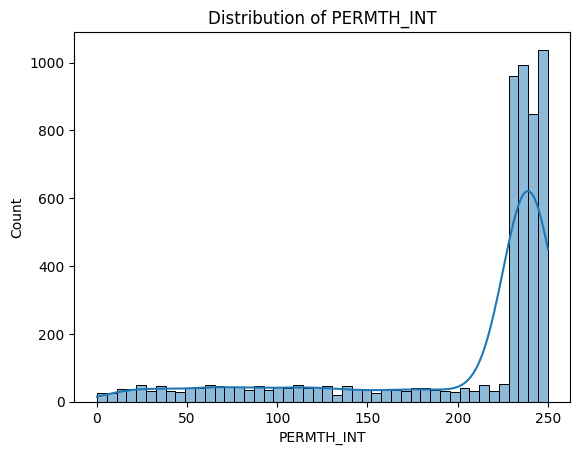

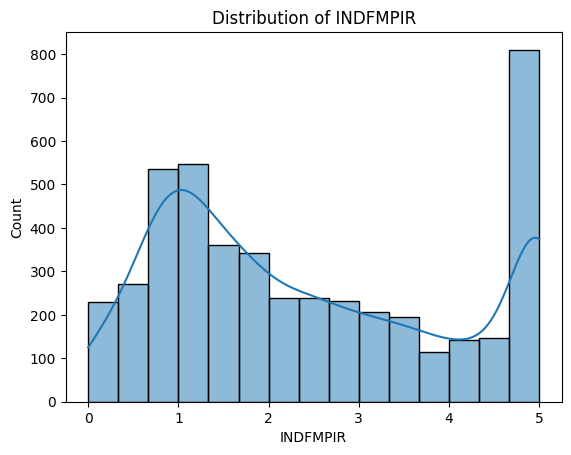

In [ ]:
for var in numeric_vars:
    plt.figure()
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

Boxplots:

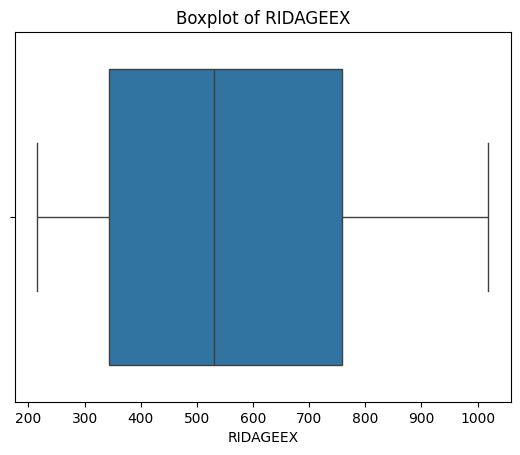

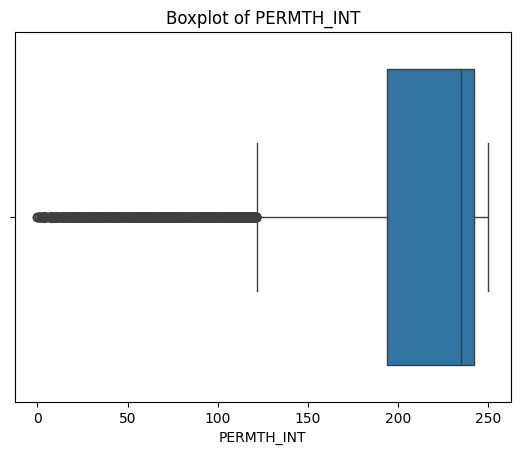

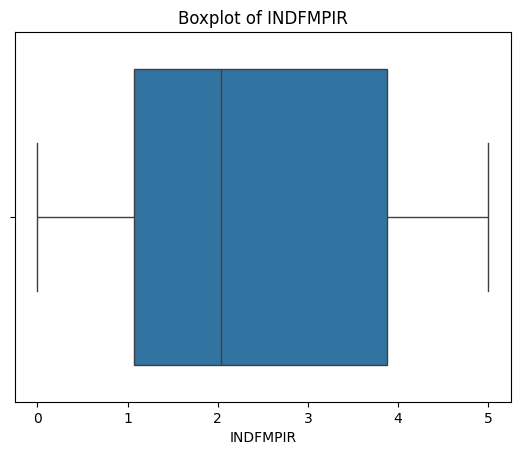

In [ ]:
for var in numeric_vars:
    plt.figure()
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot of {var}')
    plt.show()

Correlation Analysis:

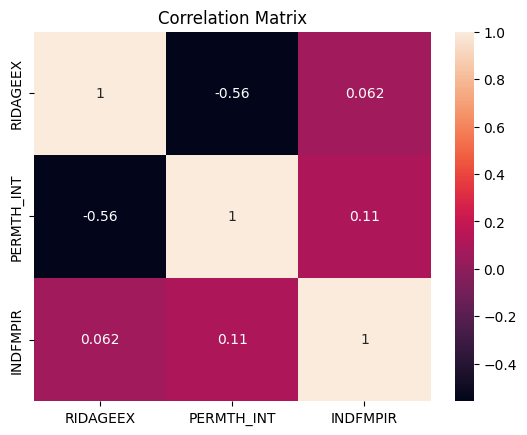

In [ ]:
corr_matrix = df[numeric_vars].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

Mortality x Race Contingency Table:

In [ ]:
pd.crosstab(df['RIDRETH1'], df['MORTSTAT'], normalize='index')

MORTSTAT,0.0,1.0
RIDRETH1,,
1.0,0.764023,0.235977
2.0,0.783383,0.216617
3.0,0.626020,0.373980
4.0,0.690821,0.309179
5.0,0.766839,0.233161


Mortality x Gender Contingency Table:

In [ ]:
pd.crosstab(df['RIAGENDR'], df['MORTSTAT'], normalize='index')

MORTSTAT,0.0,1.0
RIAGENDR,,
1.0,0.653454,0.346546
2.0,0.726614,0.273386


Categorical Variable Analysis and Contingency Tables:

In [ ]:
df['RIAGENDR'].value_counts()
df['RIDRETH1'].value_counts()

,count
RIDRETH1,
3.0,2329
1.0,1551
4.0,1035
2.0,337
5.0,193


Mortality Comparisons:

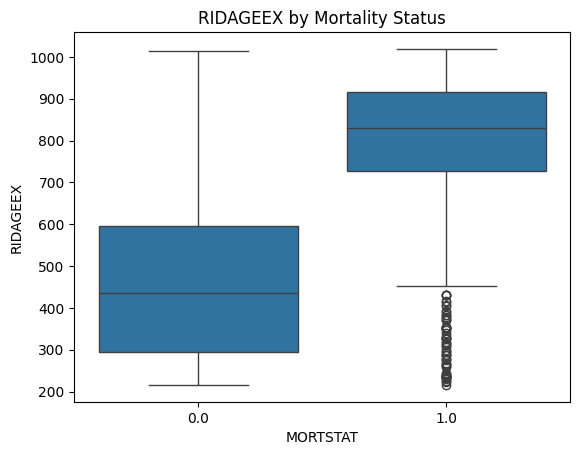

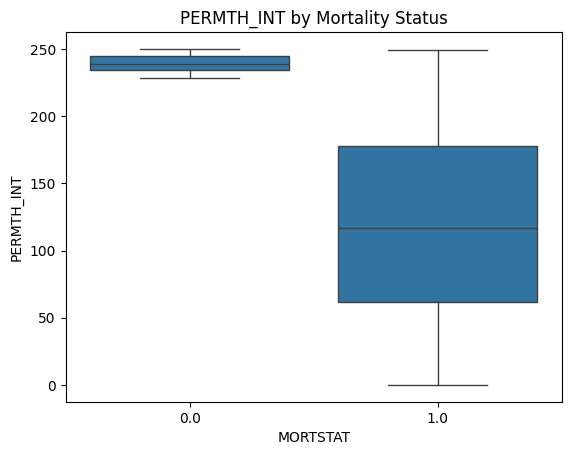

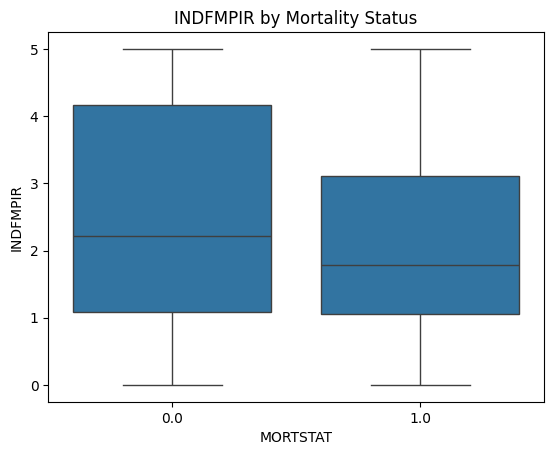

In [ ]:
df.groupby("MORTSTAT")[numeric_vars].mean()
for var in numeric_vars:
    plt.figure()
    sns.boxplot(x="MORTSTAT", y=var, data=df)
    plt.title(f"{var} by Mortality Status")
    plt.show()

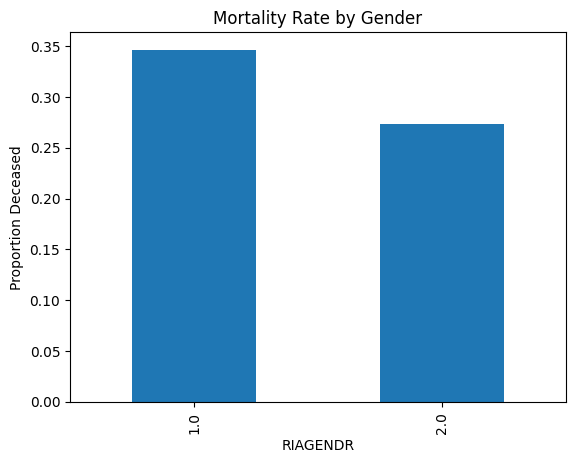

In [ ]:
mort_gender = pd.crosstab(df['RIAGENDR'], df['MORTSTAT'], normalize='index')

mort_gender[1].plot(kind='bar')
plt.title("Mortality Rate by Gender")
plt.ylabel("Proportion Deceased")
plt.show()

**Discussion**: Our data visualizations and analysis revealed that several numeric variables exhibit right skewness, particularly income-to-poverty ratio and survival time in months. Age displayed mild right skewness, reflecting a larger concentration of middle-aged respondents with fewer older individuals. Income showed stronger right skewness, consistent with the distribution of socioeconomic data. Survival time was also right-skewed due to censoring effects in the mortality data.

Boxplots indicated the presence of high-end outliers, particularly for income and survival time. These appear to reflect heterogeneity rather than data entry errors. Because k-nearest neighbors is distance-based, feature scaling will be important to remove the influence of extreme values.

Correlation analysis revealed moderate associations between age and survival time, with older individuals tending to have shorter survival durations. Other numeric variables showed relatively weak correlations, suggesting limited multicollinearity and providing complementary predictive information.

Contingency tables demonstrated meaningful differences in mortality proportions across gender and racial groups. Males exhibited higher mortality rates than females, and variation across racial categories suggests potential demographic disparities that may contribute to these values.

### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

1.
An observation in this dataset represents one individual participant in the 1999–2000 wave of the National Health and Nutrition Examination Survey (NHANES). Each row corresponds to a single person who completed the survey and medical examination and was successfully linked to the CDC Linked Mortality File
After merging the demographic file (DEMO.xpt) with the linked mortality file using the unique identifier SEQN, and restricting to ELIGSTAT = 1, our final dataset includes only adults eligible for mortality follow-up. Therefore, each observation represents: One adult participant, their demographic characteristics at baseline, their mortality status through December 31, 2019, their survival time in months (PERMTH_INT)

The CDC collects NHANES data to monitor the health of the U.S. population and to help guide public health decisions. By linking NHANES to death records, researchers can study which factors are related to survival and mortality. This makes it possible for us to use demographic variables like age, gender, race, and income to try to predict who dies and how long people live.

In our dataset, the main outcome variables, MORTSTAT and PERMTH_INT, do not have missing values after restricting to eligible participants. However, some predictor variables, such as income, have missing values. This could affect our analysis because k-nearest neighbors cannot handle missing data directly. We may need to remove or fill in missing values before building the model.

There are also some limitations to this data. First, this is observational data, so we can only find relationships, not prove cause and effect. Some information in NHANES is self-reported, which may not always be perfectly accurate. Age is also top-coded for very old participants, which reduces precision at older ages. In addition, many people were still alive at the end of the study period, so we do not know their full lifetime. Finally, all predictors were measured only at the beginning (1999–2000), and we do not see how people’s health changed over time.

2.

Based on the correlation analysis and exploratory data analysis, we selected four key variables to predict mortality and life expectancy: age in months (RIDAGEEX), gender (RIAGENDR), race/ethnicity (RIDRETH1), and income-to-poverty ratio (INDFMPIR). Age emerged as the dominant predictor, showing a strong negative correlation of -0.56 with survival time, confirming that increasing age is strongly associated with shorter remaining life expectancy. Gender was selected because contingency tables revealed meaningful disparities, with males consistently exhibiting higher mortality rates across all age groups. Race/ethnicity was included based on contingency tables showing differential mortality proportions, with Non-Hispanic Black participants demonstrating shorter average survival times, reflecting systemic health disparities. Income-to-poverty ratio showed a weak positive correlation of 0.11 with survival time and 0.062 with age, suggesting that higher income is modestly associated with longer life expectancy, though this relationship is less pronounced than age.



In [ ]:
# Generate describe table for selected variables
selected_vars = ['RIDAGEEX', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'MORTSTAT', 'PERMTH_INT']
df_selected = df[selected_vars].copy()

# Convert age to years for interpretability
df_selected['AGE_YEARS'] = df_selected['RIDAGEEX'] / 12

# Descriptive statistics table
print("Descriptive Statistics for Selected Variables:")
print("="*70)
desc_stats = df_selected[['AGE_YEARS', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'MORTSTAT', 'PERMTH_INT']].describe(include='all').round(2)
print(desc_stats)
print("\n")

Descriptive Statistics for Selected Variables:
       AGE_YEARS  RIAGENDR  RIDRETH1  INDFMPIR  MORTSTAT  PERMTH_INT
count    4840.00   5445.00   5445.00   4604.00   5445.00     5445.00
mean       46.13      1.53      2.63      2.44      0.31      202.31
std        19.62      0.50      1.18      1.61      0.46       67.14
min        18.00      1.00      1.00      0.00      0.00        0.00
25%        28.65      1.00      1.00      1.07      0.00      194.00
50%        44.17      2.00      3.00      2.04      0.00      235.00
75%        63.17      2.00      3.00      3.87      1.00      242.00
max        84.92      2.00      5.00      5.00      1.00      250.00




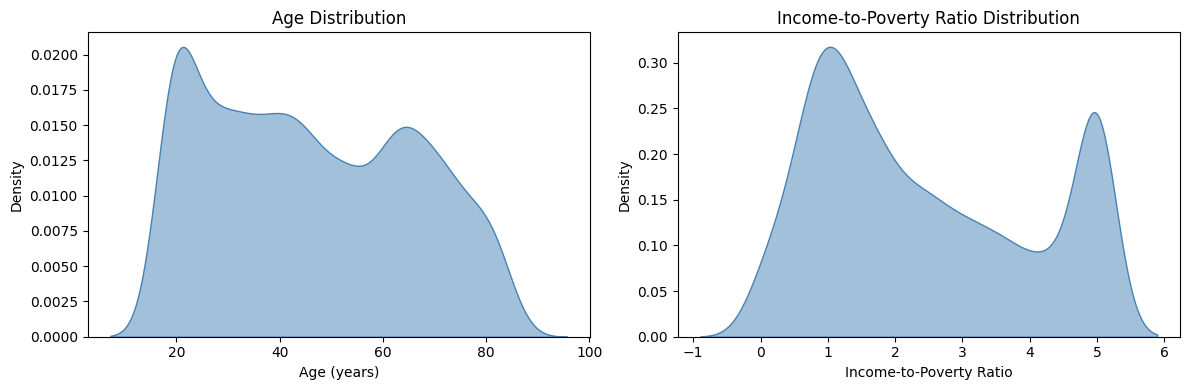

In [ ]:
# Kernel density plots for continuous variables (age and income)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
sns.kdeplot(data=df_selected, x='AGE_YEARS', ax=axes[0], fill=True, alpha=0.5, color='steelblue')
axes[0].set_title('Age Distribution', fontsize=12)
axes[0].set_xlabel('Age (years)')

# Income distribution
sns.kdeplot(data=df_selected, x='INDFMPIR', ax=axes[1], fill=True, alpha=0.5, color='steelblue')
axes[1].set_title('Income-to-Poverty Ratio Distribution', fontsize=12)
axes[1].set_xlabel('Income-to-Poverty Ratio')

plt.tight_layout()
plt.show()

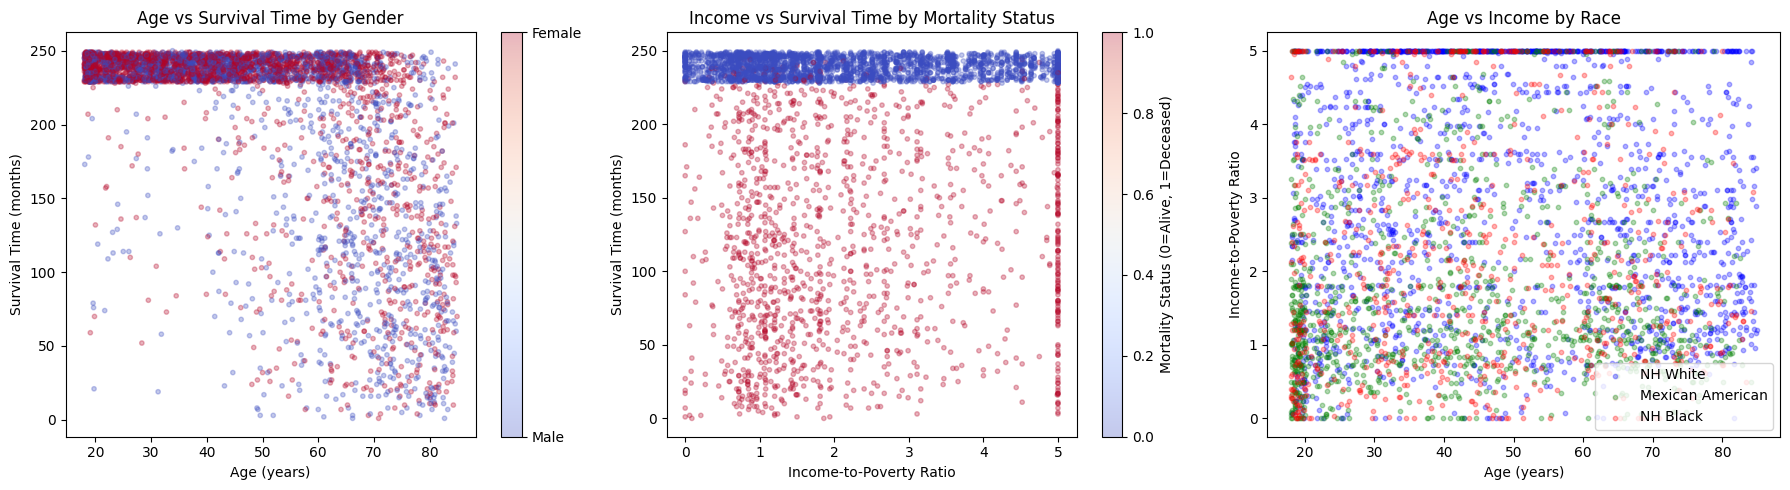

In [ ]:
# Scatter plots to examine relationships between continuous variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Survival Time (colored by gender)
scatter1 = axes[0].scatter(df_selected['AGE_YEARS'], df_selected['PERMTH_INT'],
                          c=df_selected['RIAGENDR'], cmap='coolwarm', alpha=0.3, s=10)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Survival Time (months)')
axes[0].set_title('Age vs Survival Time by Gender')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_ticks([1, 2])
cbar1.set_ticklabels(['Male', 'Female'])

# Income vs Survival Time (colored by mortality)
scatter2 = axes[1].scatter(df_selected['INDFMPIR'], df_selected['PERMTH_INT'],
                          c=df_selected['MORTSTAT'], cmap='coolwarm', alpha=0.3, s=10)
axes[1].set_xlabel('Income-to-Poverty Ratio')
axes[1].set_ylabel('Survival Time (months)')
axes[1].set_title('Income vs Survival Time by Mortality Status')
plt.colorbar(scatter2, ax=axes[1], label='Mortality Status (0=Alive, 1=Deceased)')

# Age vs Income (colored by race - using top 3 races for clarity)
top_races = df_selected['RIDRETH1'].value_counts().head(3).index
df_race_subset = df_selected[df_selected['RIDRETH1'].isin(top_races)]
race_colors = {3: 'blue', 4: 'red', 1: 'green'}  # NH White, NH Black, Mexican American
race_labels_display = {3: 'NH White', 4: 'NH Black', 1: 'Mexican American'}

for race in top_races:
    subset = df_race_subset[df_race_subset['RIDRETH1'] == race]
    axes[2].scatter(subset['AGE_YEARS'], subset['INDFMPIR'],
                   c=race_colors[race], label=race_labels_display[race], alpha=0.3, s=10)
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Income-to-Poverty Ratio')
axes[2].set_title('Age vs Income by Race')
axes[2].legend()

plt.tight_layout()
plt.show()

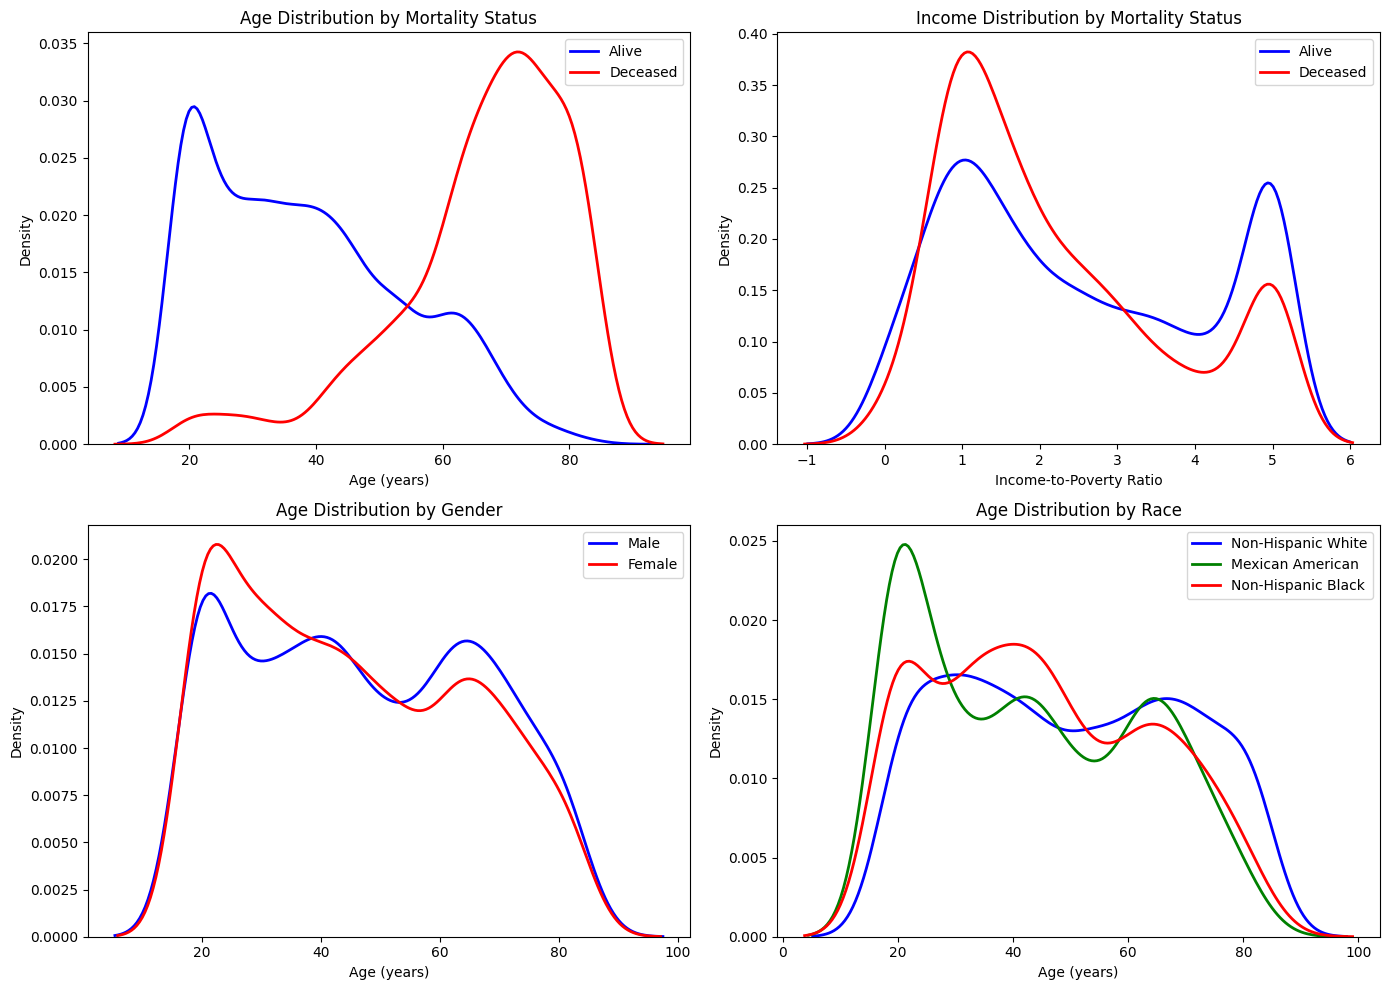

In [ ]:
# Conditional kernel densities by mortality status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age conditional on mortality
for mort_status, color, label in [(0, 'blue', 'Alive'), (1, 'red', 'Deceased')]:
    subset = df_selected[df_selected['MORTSTAT'] == mort_status]['AGE_YEARS'].dropna()
    sns.kdeplot(x=subset, color=color, label=label, ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title('Age Distribution by Mortality Status', fontsize=12)
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].legend()

# Income conditional on mortality
for mort_status, color, label in [(0, 'blue', 'Alive'), (1, 'red', 'Deceased')]:
    subset = df_selected[df_selected['MORTSTAT'] == mort_status]['INDFMPIR'].dropna()
    sns.kdeplot(x=subset, color=color, label=label, ax=axes[0, 1], linewidth=2)
axes[0, 1].set_title('Income Distribution by Mortality Status', fontsize=12)
axes[0, 1].set_xlabel('Income-to-Poverty Ratio')
axes[0, 1].legend()

# Age conditional on gender
for gender, color, label in [(1, 'blue', 'Male'), (2, 'red', 'Female')]:
    subset = df_selected[df_selected['RIAGENDR'] == gender]['AGE_YEARS'].dropna()
    sns.kdeplot(x=subset, color=color, label=label, ax=axes[1, 0], linewidth=2)
axes[1, 0].set_title('Age Distribution by Gender', fontsize=12)
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].legend()

# Age conditional on race (top 3 races)
top_races = df_selected['RIDRETH1'].value_counts().head(3).index
race_colors = {3: 'blue', 4: 'red', 1: 'green'}
race_display = {1: 'Mexican American', 3: 'Non-Hispanic White', 4: 'Non-Hispanic Black'}

for race in top_races:
    subset = df_selected[df_selected['RIDRETH1'] == race]['AGE_YEARS'].dropna()
    sns.kdeplot(x=subset, color=race_colors[race], label=race_display[race],
                ax=axes[1, 1], linewidth=2)
axes[1, 1].set_title('Age Distribution by Race', fontsize=12)
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The distributions show several clear demographic patterns related to mortality. Age is the strongest distinguishing factor: individuals who are deceased are heavily concentrated at older ages (especially 65–85), while those who are alive are primarily younger and middle-aged, indicating a strong age gradient in mortality risk. Income also exhibits a clear socioeconomic pattern, with deceased individuals more concentrated at lower income-to-poverty ratios and alive individuals more represented at higher ratios, suggesting that higher income may be protective. In contrast, age distributions by gender are largely similar, though females appear slightly more represented at older ages, consistent with longer life expectancy. Finally, age distributions differ by race, with Mexican American individuals skewing younger overall, Non-Hispanic White individuals showing greater representation at older ages, and Non-Hispanic Black individuals more concentrated in younger and middle adulthood. Together, these patterns suggest that age is the dominant factor associated with mortality, with income and demographic structure also playing important roles.



3.
 Using your variables to predict mortality using a  k -Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select  k

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

variables = ['RIDAGEEX', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR']
target = 'MORTSTAT'
# dropping missing data
model_df = df_selected[variables + [target]].dropna()
#set-up
y = model_df[target]
x = model_df.loc[:, variables]
#scaling variables
scaler = MinMaxScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns, index=x.index)
#train_test_split
u_train, u_test, y_train, y_test = train_test_split(x_scaled, y,
                                                    test_size=.2,
                                                    random_state=100)


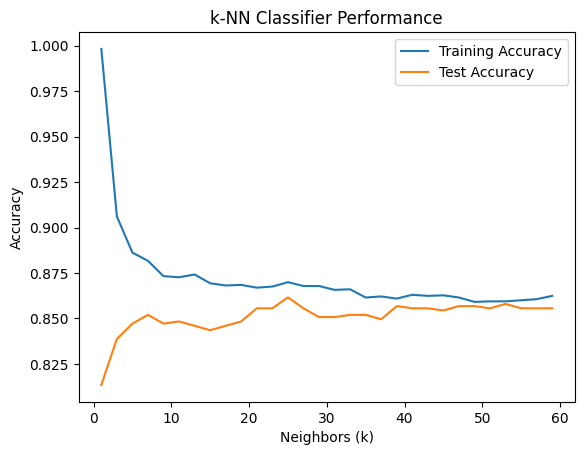

The optimal value of k is: 25 with a Test Accuracy of 0.862


In [ ]:
#Selecting k
k_grid = np.array([ (2*k + 1) for k in range(0, 30) ]) # Testing k = 1, 3, 5, ..., 59

test_accuracies = []
train_accuracies = []
for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
# creating a model instance
    model.fit(u_train, y_train)
    y_hat = model.predict(u_test)
    test_acc = model.score(u_test, y_test)
    test_accuracies.append(test_acc)

# evaluating train part to see overfitting
    train_acc = model.score(u_train, y_train)
    train_accuracies.append(train_acc)

# Visualization of results to find the optimal k
sns.lineplot(x=k_grid, y=train_accuracies, label='Training Accuracy').set(xlabel='Neighbors (k)', ylabel='Accuracy')
sns.lineplot(x=k_grid, y=test_accuracies, label='Test Accuracy')
plt.title('k-NN Classifier Performance')
plt.show()

#Determining the optimal k based on the highest test accuracy
# Find the k that maximizes test accuracy
optimal_k_index = np.argmax(test_accuracies)
optimal_k = k_grid[optimal_k_index]
optimal_test_acc = test_accuracies[optimal_k_index]

print(f"The optimal value of k is: {optimal_k} with a Test Accuracy of {optimal_test_acc:.3f}")

The plot created to compare training to test accuracy. Here we find the k where text accuracy is the highest. This point is where we see the best balance in under and overfitting. This was done by training kNN classifiers with different k-values on the training data and then checked how they did on the test set. This test set was acting as a stand in for new data that would create an overfitting. Odd values of k were only used because I wanted to avoid tie situations. I then compared the training and test accuracy with different k values to help check for over and underfitting.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

final_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_model.fit(u_train, y_train)

y_pred = final_model.predict(u_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

baseline = max(y_test.mean(), 1 - y_test.mean())
print("Baseline Accuracy:", baseline)

[[563  46]
 [ 69 153]]
              precision    recall  f1-score   support

         0.0       0.89      0.92      0.91       609
         1.0       0.77      0.69      0.73       222

    accuracy                           0.86       831
   macro avg       0.83      0.81      0.82       831
weighted avg       0.86      0.86      0.86       831

Baseline Accuracy: 0.7328519855595668


Using the selected value of k = 25, the model achieved a test accuracy of 0.86. This is higher than the baseline accuracy of 0.73, which represents always predicting the majority class (alive). This indicates that the model provides meaningful improvement over a naive prediction strategy. The confusion matrix shows that 563 individuals who were alive were correctly classified, while 153 deceased individuals were correctly identified. However, 69 deceased individuals were incorrectly predicted as alive. This results in a recall of 0.69 for the deceased class, meaning the model correctly identifies about 69% of individuals who died. Overall, the model performs better at predicting survival than mortality, but still captures a substantial portion of high-risk individuals.

In [ ]:
# Initialize the final model with the optimal k found
final_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_model.fit(u_train, y_train)

# Make predictions on the test set
y_pred = final_model.predict(u_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

Predicted,0.0,1.0
Actual,,
0.0,563,46
1.0,69,153


4.
Using your variables to predict life expectancy using a  k -Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select  k

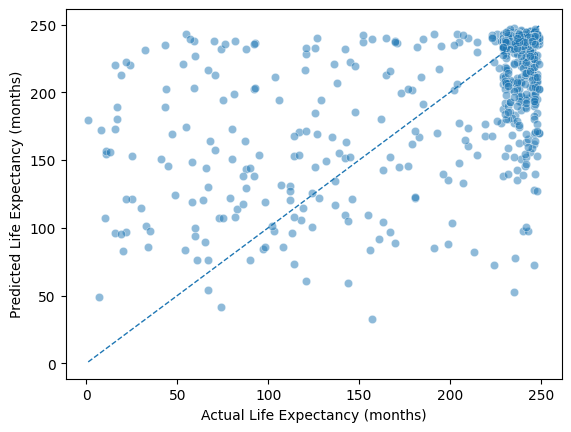

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Define features and target
ctrl_list = ['RIDAGEEX', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR']
target_var = 'PERMTH_INT'

# Create a DataFrame with selected variables and target, then drop NaNs
regression_df = df[ctrl_list + [target_var]].dropna()

# Set up features (x) and target (y) from the cleaned DataFrame
x = regression_df.loc[:, ctrl_list]
y = regression_df[target_var]

# Scaling the variables using MinMaxScaler
scaler = MinMaxScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns, index=x.index)

# train_test_split
u_train, u_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=100)

# Fit a kNN Regressor and Predict
k = 5
model = KNeighborsRegressor(n_neighbors=k)
model = model.fit(u_train, y_train)
y_hat = model.predict(u_test)

#Visualize the Predictor
sns.scatterplot(x=y_test, y=y_hat, alpha=0.5)
plt.xlabel('Actual Life Expectancy (months)')
plt.ylabel('Predicted Life Expectancy (months)')
lo = np.min([y_test.min(), y_hat.min()])
hi = np.max([y_test.max(), y_hat.max()])
plt.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1, label='y = ŷ')


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse_5 = mean_squared_error(y_test, y_hat)
rmse_5 = np.sqrt(mse_5)
print("k=5 MSE:", mse_5)
print("k=5 RMSE:", rmse_5)

k=5 MSE: 2583.870324909747
k=5 RMSE: 50.83178459300585


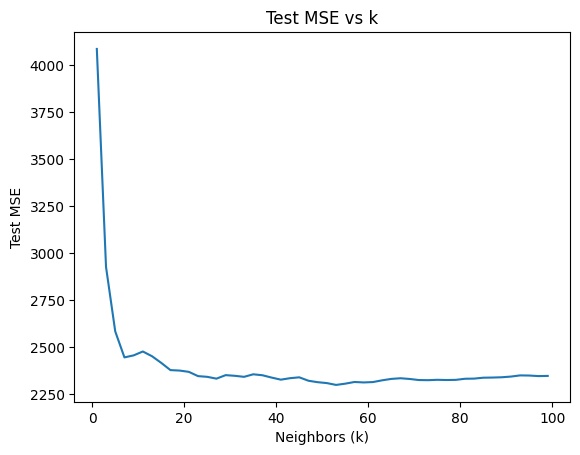

Optimal k: 53


In [ ]:
k_grid = [2*k+1 for k in range(50)]  # odd k
mses = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(u_train, y_train)
    y_hat_k = model.predict(u_test)
    mses.append(mean_squared_error(y_test, y_hat_k))

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=k_grid, y=mses)
plt.xlabel("Neighbors (k)")
plt.ylabel("Test MSE")
plt.title("Test MSE vs k")
plt.show()

optimal_k = k_grid[np.argmin(mses)]
print("Optimal k:", optimal_k)

In [ ]:
model = KNeighborsRegressor(n_neighbors=optimal_k)
model.fit(u_train, y_train)

y_hat = model.predict(u_test)

final_mse = mean_squared_error(y_test, y_hat)
final_rmse = np.sqrt(final_mse)

print("Final MSE:", final_mse)
print("Final RMSE:", final_rmse)

Final MSE: 2299.1900783925144
Final RMSE: 47.9498704731568


Using the optimal value of k = 53 selected by minimizing test MSE, the final model achieved a test RMSE of approximately 47.95 months. This means that, on average, the model's predictions are about 48 months away from the true survival time.

The scatter plot of actual versus predicted values shows that predictions generally follow the diagonal line, but there is noticeable spread, especially at higher survival times. This suggests that while the model captures general survival patterns, it has larger prediction errors for extreme values.

Comparing training and test MSE, we observe that training error is lower than test error, as expected. However, the gap is not extreme, suggesting the model is not severely overfitting. As k increases, MSE initially decreases and then stabilizes, indicating that moderate neighborhood sizes provide the best balance between bias and variance.

Overall, the kNN regression model provides reasonable predictive performance but does not perfectly capture individual-level survival variation.

<Axes: >

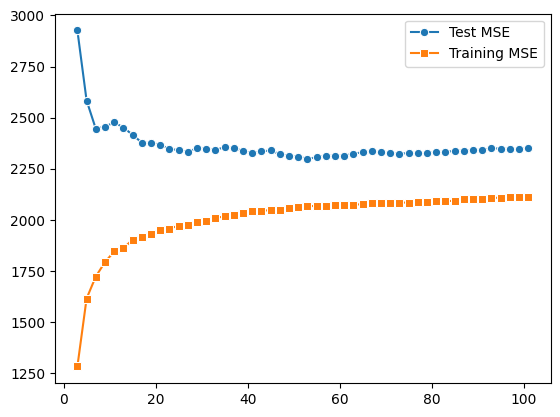

In [ ]:
#Mean Squared Error
def mse(y_test, y_hat):
    mse = np.sum((y_test - y_hat) ** 2) / len(y_test)
    return mse
#training vs test MSE
k_grid = [(2*k + 1) for k in range(1, 51)]  # Odd numbers from 3 to 101
mses_test = []
mses_train = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(u_train, y_train)
    y_hat_test = model.predict(u_test)
    y_hat_train = model.predict(u_train)
    mses_test.append(mse(y_test, y_hat_test))
    mses_train.append(mse(y_train, y_hat_train))
sns.lineplot(x=k_grid, y=mses_test, label='Test MSE', marker='o')
sns.lineplot(x=k_grid, y=mses_train, label='Training MSE', marker='s')

In [ ]:
#picking k
index_star = np.argmin(mses_test)
k_star = k_grid[index_star]
min_test_mse = mses_test[index_star]

print(f"\nOptimal k: {k_star}")
print(f"Minimum Test MSE: {min_test_mse:.2f}")
print(f"Minimum Test RMSE: {np.sqrt(min_test_mse):.2f} months")
print(f"R² Score at optimal k: {KNeighborsRegressor(n_neighbors=k_star).fit(u_train, y_train).score(u_test, y_test):.4f}")


Optimal k: 53
Minimum Test MSE: 2299.19
Minimum Test RMSE: 47.95 months
R² Score at optimal k: 0.3863


k was selected by first testing out ranges of k values from 3-101. MSE was then tested for each of the k value, and this allowed for the k with the minimum test MSE to be chosen, which in this case was k=53. This ultimately allows for a bias variance tradeoff, where the the model is balancing the bias and variance. The overall performance lets us know that age is a strong predictor of life expectancy.

5.
Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider?



Our model could be used by healthcare systems to identify patients who may be at higher risk based on demographic characteristics such as age, gender, race/ethnicity, and income level.

In the classification model, we predict mortality status. If the model predicts that a patient has a higher probability of death, healthcare providers could use this information to offer earlier screenings, closer monitoring, or preventive treatments. This could help prioritize patients who may need more immediate attention.

In the regression model, we predict survival time in months. If a patient is predicted to have shorter survival time, doctors might allocate additional medical resources, adjust treatment plans, or provide supportive services. In this way, the model could assist in planning and distributing healthcare resources more efficiently.

However, there are important limitations and risks to consider. First, the model uses only a small set of demographic variables and does not include detailed medical information such as diagnoses, treatment history, or lifestyle factors. As a result, the predictions may not fully capture a patient’s true health condition.

Second, variables like race and income reflect broader social and structural inequalities. If these variables are used without careful interpretation, the model could unintentionally reinforce existing health disparities.

Finally, k-nearest neighbors is sensitive to how the data is scaled and to the structure of the training data. If the dataset is not representative of the broader population, the predictions may be biased. Therefore, this model should be used as a supportive decision-making tool rather than a replacement for professional medical judgment.

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)